<a href="https://colab.research.google.com/github/cookmo/Cook_NEUR265/blob/main/coding_homework_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Morgan Cook
*NEUR265: Introduction to Neural Data Analysis*

**April 9, 2026**

In [4]:
# Importing modules (#2)
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

In [5]:
# Importing data (#3)
fear_traces = np.loadtxt('https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/fear_conditioning_traces_hw8.csv', delimiter=',')
extinction_predictors = np.loadtxt('https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/extinction_predictors_hw8.csv', delimiter=',')
shock_index = np.loadtxt('https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/shock_index.csv', delimiter=',').astype(int)
tone_index = np.loadtxt('https://raw.githubusercontent.com/hallockh/neur_265_spring2026/refs/heads/main/data/tone_index.csv', delimiter=',').astype(int)

In [6]:
# Making new variables (#5)
conditioning_traces = fear_traces[:10458, :]
extinction_traces = fear_traces[10457:, :]

In [14]:
# Printing size of variables (#6)
print(conditioning_traces.size)
print(extinction_traces.size)
print(conditioning_traces.shape)
print(extinction_traces.shape)

658854
895293
(10458, 63)
(14211, 63)


In [15]:
# Making new variables (#7)
time_conditioning = np.linspace(0, 10458/15, 10458)
time_extinction = np.linspace(0, 14211/15, 14211)

During these sessions, 63 ROIs were imaged. The conditioning session was 697.2 seconds and the extinction session was 947.4 seconds.

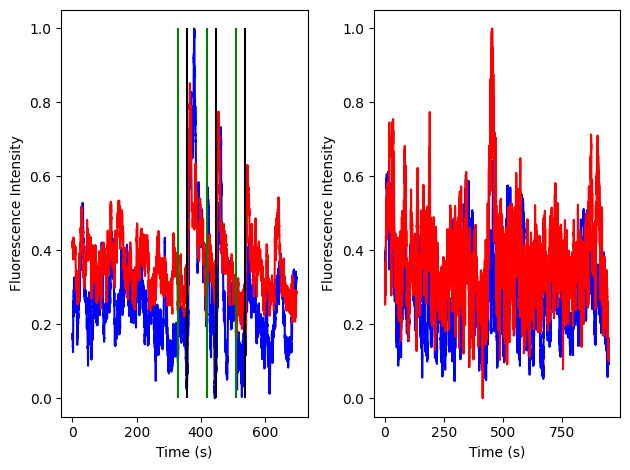

In [23]:
# Creating subplots (#9)
fig, ax = plt.subplots(1,2)

ax[0].plot(time_conditioning, conditioning_traces[:,0], color='b')
ax[0].plot(time_conditioning, conditioning_traces[:,1], color='r')

ax[1].plot(time_extinction, extinction_traces[:,0], color='b')
ax[1].plot(time_extinction, extinction_traces[:,1], color='r')

ax[0].vlines(shock_index, 0, 1, color='black')
ax[0].vlines(tone_index, 0, 1, color='green')

ax[0].set_xlabel('Time (s)')
ax[0].set_ylabel('Fluorescence Intensity')

ax[1].set_xlabel('Time (s)')
ax[1].set_ylabel('Fluorescence Intensity')

plt.tight_layout()

The first ROI's conditioning session shows fluorescence intensity noticeably increases after the first shock occured. However, this is not seen after the tone. The sharpest increase in fluorescence takes place after the first occurence of the shock, after this, each reaction (of fluoresence increase) becoming less noticeable. The second ROI's conditioning session appeared to follow the same pattern. The extinction session showed a higher overall fluorescence intensity than that of the conditioning session before any shocks had been given. This was seen throughout both ROIs.

In [29]:
#Making predictors_conditioning variable (#12)
from pandas import DataFrame as df

shock_array = np.zeros(10458)
for i in range(10458):
  if i >= (shock_index[0]-15)*15 and i <= (shock_index[0]+30)*15:
    shock_array[i] = 1
  elif i>= (shock_index[1]-15)*15 and i <= (shock_index[1]+30)*15:
    shock_array[i] = 1
  elif i>= (shock_index[2]-15)*15 and i <= (shock_index[2]+30)*15:
    shock_array[i] = 1
  else:
    shock_array[i] = 0

tone_array = np.zeros(10458)
for i in range(10458):
  if i >= (tone_index[0]-15)*15 and i <= (tone_index[0]+30)*15:
    tone_array[i] = 1
  elif i>= (tone_index[1]-15)*15 and i <= (tone_index[1]+30)*15:
    tone_array[i] = 1
  elif i>= (tone_index[2]-15)*15 and i <= (tone_index[2]+30)*15:
    tone_array[i] = 1
  else:
    tone_array[i] = 0


predictors_conditioning = df(data={'Intercept': np.ones_like(tone_array), 'tone onset': tone_array})
predictors_conditioning['shock onset'] = shock_array

In [31]:
# Run model for each ROI in our conditioning_traces array (#13)
import statsmodels.api as sm
from statsmodels.genmod.families import Poisson

r_model_conditioning = np.zeros(63)

for i in range(63):
  trace_temp = conditioning_traces[:,i]
  model3 = sm.GLM(trace_temp, predictors_conditioning, family=Poisson())
  model3_results = model3.fit()
  predicted_trace = model3_results.predict()
  r3 = pearsonr(trace_temp, predicted_trace)
  r_model_conditioning[i] = r3.statistic

In [32]:
# Run model for each ROI in our extinction_traces array (#14)
r_model_extinction = np.zeros(63)

for i in range(63):
  trace_temp = extinction_traces[:,i]
  model3 = sm.GLM(trace_temp, extinction_predictors, family=Poisson())
  model3_results = model3.fit()
  predicted_trace = model3_results.predict()
  r3 = pearsonr(trace_temp, predicted_trace)
  r_model_extinction[i] = r3.statistic

In [33]:
# Using pearsonr to correlate variables (#15)
pearsonr(r_model_conditioning, r_model_extinction)

PearsonRResult(statistic=np.float64(0.014135850678388082), pvalue=np.float64(0.9124422932886772))

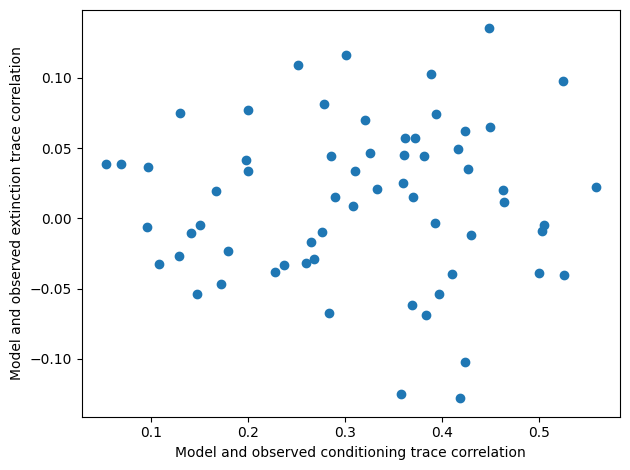

In [36]:
# Making a scatter plot (#16)
plt.scatter(r_model_conditioning, r_model_extinction)

plt.xlabel('Model and observed conditioning trace correlation')
plt.ylabel('Model and observed extinction trace correlation')

plt.tight_layout()

Looking at the points on the scatterplot above, there is no easily detectable pattern that would represent a correlation between the data. There does not seem to be a significant relationship between the variables.